<a href="https://colab.research.google.com/github/tarekhammam73-ai/materials-bandgap-screening/blob/main/band_gap_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Predicting Experimental Band Gaps from Chemical Composition
### A Data-Driven Materials Screening Workflow

**Author:** [Tarek M. Hammam]  
**Dataset:** `matbench_expt_gap` (Matminer / Matbench)  
**Goal:** Use machine learning to predict the experimental electronic band gap (in eV) of inorganic materials from their chemical composition alone, then screen candidates for solar energy applications (target: 1.0 – 3.0 eV).

---

### Why does band gap matter?
The band gap is the energy difference between the valence and conduction bands of a material. It determines whether a material is an insulator, semiconductor, or conductor. For photovoltaics (solar cells), a band gap near **1.5 eV** is ideal — it matches the peak of the solar spectrum. Discovering new semiconductors computationally, before expensive synthesis, is a key goal of modern materials informatics. This approach is particularly relevant for accelerating materials discovery, where traditional experimental trial-and-error methods are slow and resource-intensive.

---

## Research Objective

The goal of this project is to identify candidate materials with semiconductor-relevant band gaps (1–3 eV) using a data-driven approach.

This demonstrates how machine learning can assist in materials screening. This project is intended as a proof-of-concept workflow rather than a fully optimized predictive model.


## Section 1 — Setup & Installation

We install the required Python libraries. This only needs to be done once per Colab session.

- **matminer**: loads materials datasets and computes composition-based features  
- **scikit-learn**: machine learning algorithms and evaluation  
- **pandas / numpy**: data handling  
- **matplotlib**: plotting

In [1]:
# Install required libraries
# This may take 1–2 minutes — run it once at the start of your session
!pip install matminer --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━

> **Note:** The `--quiet` flag suppresses verbose output. If you see a warning about restarting the runtime, do so and then skip this cell on re-run.

## Section 2 — Imports

We load all the tools we will use throughout the notebook.

In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')  # Suppress non-critical warnings for clean output

# ── Data handling ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Matminer: dataset loading and featurization ───────────────────────────────
from matminer.datasets import load_dataset
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import StrToComposition

# ── Machine learning (scikit-learn) ───────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model  import LinearRegression
from sklearn.ensemble      import RandomForestRegressor
from sklearn.metrics       import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print("All libraries imported successfully.")

All libraries imported successfully.


> Each import block is labeled so you know what each library is used for. If any import fails, re-run Section 1.

## Section 3 — Load Dataset

We use the **`matbench_expt_gap`** dataset from Matminer. This dataset contains ~4,604 experimentally measured band gaps for inorganic compounds, compiled from peer-reviewed literature. Each entry has:

- `composition`: the chemical formula (e.g., `GaAs`, `TiO2`)
- `gap expt`: the measured band gap in electron-volts (eV)

In [3]:
# Load the experimental band gap dataset
# This downloads ~2 MB from the Matminer servers on first run
df = load_dataset("matbench_expt_gap")

print(f"Dataset loaded: {len(df)} entries")
print(f"Columns: {list(df.columns)}")
print()
df.head(10)

Fetching matbench_expt_gap.json.gz from https://ml.materialsproject.org/projects/matbench_expt_gap.json.gz to /usr/local/lib/python3.12/dist-packages/matminer/datasets/matbench_expt_gap.json.gz


Fetching https://ml.materialsproject.org/projects/matbench_expt_gap.json.gz in MB: 0.038911999999999995MB [00:00, 14.24MB/s]   

Dataset loaded: 4604 entries
Columns: ['composition', 'gap expt']



,composition,gap expt
0,Ag(AuS)2,0.00
1,Ag(W3Br7)2,0.00
2,Ag0.5Ge1Pb1.75S4,1.83
3,Ag0.5Ge1Pb1.75Se4,1.51
4,Ag2BBr,0.00
5,Ag2BiO3,0.00
6,Ag2GeS3,1.98
7,Ag2GeSe3,0.90
8,Ag2HgI4,2.47
9,Ag2Mo(I2O7)2,3.06


> The dataset was compiled by Zhuo et al. (2018) and covers a wide range of experimentally characterized semiconductors and insulators. It is a standard benchmark in materials informatics.

## Section 4 — Data Cleaning

Before modeling, we inspect the data for issues:
- Missing values (NaNs)
- Physically unrealistic band gap values (negative or extremely large)
- Duplicate entries

We also examine the distribution of the target variable.

In [4]:
# ── Rename columns to simple names for convenience ────────────────────────────
df = df.rename(columns={'gap expt': 'band_gap'})

# ── Check for missing values ──────────────────────────────────────────────────
print("Missing values per column:")
print(df.isnull().sum())
print()

# ── Check basic statistics ────────────────────────────────────────────────────
print("Band gap statistics (eV):")
print(df['band_gap'].describe().round(3))
print()

# ── Remove physically unrealistic values ─────────────────────────────────────
# Band gaps < 0 are unphysical; > 20 eV are wide-gap insulators rarely relevant
before = len(df)
df = df[df['band_gap'] >= 0.0]
df = df[df['band_gap'] <= 20.0]
after = len(df)
print(f"Removed {before - after} entries with unphysical band gaps.")

# ── Remove duplicate compositions ────────────────────────────────────────────
df = df.drop_duplicates(subset='composition')
print(f"Entries after deduplication: {len(df)}")

Missing values per column:
composition    0
band_gap       0
dtype: int64

Band gap statistics (eV):
count    4604.000
mean        0.976
std         1.445
min         0.000
25%         0.000
50%         0.000
75%         1.812
max        11.700
Name: band_gap, dtype: float64

Removed 0 entries with unphysical band gaps.
Entries after deduplication: 4604


> Cleaning data is a critical step in any ML project. Garbage in = garbage out. Here we remove a small number of physically implausible entries to ensure model training is grounded in realistic measurements.

## Section 5 — Composition Conversion

Machine learning models cannot directly read text like `"GaAs"`. We convert the composition strings into **pymatgen Composition objects**, which understand the chemical elements and their ratios. This is a prerequisite for feature engineering.

In [5]:
# Convert composition strings → pymatgen Composition objects
# StrToComposition adds a new column 'composition_obj' with the parsed objects

stc = StrToComposition(target_col_id='composition_obj')
df = stc.featurize_dataframe(df, col_id='composition', ignore_errors=True)

# Drop any rows where conversion failed
df = df.dropna(subset=['composition_obj'])

print(f"Compositions converted successfully: {len(df)} entries remain")
print()
print("Example Composition object:")
print(df['composition_obj'].iloc[0])

StrToComposition:   0%|          | 0/4604 [00:00<?, ?it/s]

Compositions converted successfully: 4604 entries remain

Example Composition object:
Ag1 Au2 S2


> A `pymatgen` Composition object stores the chemical formula in a structured way — it knows that `GaAs` contains equal parts gallium (Ga) and arsenic (As), and can provide elemental properties for each.

## Section 6 — Feature Engineering (Magpie Preset)

This is the heart of composition-based materials informatics.

We use the **Magpie** (Materials Agnostic Platform for Informatics and Exploration) descriptor set, developed by Ward et al. (2016). For each composition, Magpie generates **132 numerical features** based on the elemental properties of the constituent atoms, including:

- Atomic number, atomic mass, electronegativity  
- Melting point, boiling point, molar volume  
- Number of valence electrons, band filling  
- Row/column in the periodic table  

For each property, it computes the **mean, range, minimum, maximum, mode, and standard deviation** across the elements in the formula — giving 132 numbers that numerically describe each material.

In [6]:
# Initialize the Magpie featurizer with the 'magpie' preset
ep = ElementProperty.from_preset('magpie')

# Apply featurization to the dataframe
# This computes 132 features per row — may take 1–2 minutes
print("Computing Magpie features... (this may take ~1-2 minutes)")
df = ep.featurize_dataframe(df, col_id='composition_obj', ignore_errors=True)

# Drop rows where featurization failed
df = df.dropna()

print(f"Featurization complete. Dataset shape: {df.shape}")
print(f"Number of Magpie features: {len(ep.feature_labels())}")

Computing Magpie features... (this may take ~1-2 minutes)


ElementProperty:   0%|          | 0/4604 [00:00<?, ?it/s]

Featurization complete. Dataset shape: (4604, 135)
Number of Magpie features: 132


In [7]:
# Extract features (X) and target (y)
feature_cols = ep.feature_labels()

X = df[feature_cols].values   # Shape: (n_samples, 132)
y = df['band_gap'].values      # Shape: (n_samples,)

print(f"Feature matrix X: {X.shape}  (rows = materials, columns = features)")
print(f"Target vector  y: {y.shape}  (band gap in eV)")

Feature matrix X: (4604, 132)  (rows = materials, columns = features)
Target vector  y: (4604,)  (band gap in eV)


> **Why Magpie?** It is one of the most widely validated feature sets in materials informatics, used in hundreds of peer-reviewed publications. It works well with tree-based models like Random Forest because the features have clear physical meaning.

## Section 7 — Train / Test Split

We split our data into a **training set** (80%) and a **test set** (20%). The model is trained only on the training set. The test set is held out until evaluation — it simulates unseen materials that the model has never encountered.

We also apply **StandardScaler** to normalize the features for Linear Regression (Random Forest does not require this, but we apply it to both for consistency).

In [8]:
# Split: 80% train, 20% test
# random_state=42 ensures reproducibility — same split every run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set:  {X_train.shape[0]} materials")
print(f"Test set:      {X_test.shape[0]} materials")

# Scale features (zero mean, unit variance)
# Fit ONLY on training data to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # Apply same scaling to test set

print("\nFeature scaling applied.")

Training set:  3683 materials
Test set:      921 materials

Feature scaling applied.


> **Important:** We fit the scaler only on training data, then apply the same transformation to the test set. Fitting on the full dataset would "leak" test information into training — a common but critical mistake.

## Section 8 — Linear Regression (Baseline Model)

Linear Regression is our **baseline** — the simplest possible model. It assumes band gap is a weighted linear combination of the 132 Magpie features. Its purpose is not to be the best model, but to give us a reference point: if a more complex model can't beat it, it's not worth using.

In [9]:
# Train Linear Regression on the scaled training data
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_lr = lr.predict(X_test_scaled)

# Clip negative predictions to 0 (band gap cannot be negative)
y_pred_lr = np.clip(y_pred_lr, 0, None)

# Compute evaluation metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)

print("Linear Regression — Test Set Performance")
print(f"  MAE : {mae_lr:.3f} eV")
print(f"  R²  : {r2_lr:.3f}")

Linear Regression — Test Set Performance
  MAE : 47.456 eV
  R²  : -933920.027


> **What do these metrics mean?**
> - **MAE (Mean Absolute Error):** On average, how many eV away is our prediction from the true band gap? Lower is better. An MAE of 0.5 eV means we're off by half an electron-volt on average.
> - **R² (coefficient of determination):** How much of the variance in band gap does our model explain? 1.0 = perfect; 0.0 = no better than predicting the mean. Negative values are possible for very poor models.

## Section 9 — Random Forest (Main Model)

Random Forest is an **ensemble method** — it builds many decision trees on random subsets of the data and features, then averages their predictions. It handles non-linear relationships between features and band gap, which linear regression cannot capture.

Key hyperparameters:
- `n_estimators=200`: number of decision trees in the forest
- `max_features='sqrt'`: each tree considers √132 ≈ 11 features at each split
- `random_state=42`: ensures reproducibility

In [10]:
# Train Random Forest on the UNSCALED training data
# Decision trees are invariant to feature scaling
print("Training Random Forest... (this may take ~30 seconds)")

rf = RandomForestRegressor(
    n_estimators=200,
    max_features='sqrt',
    min_samples_leaf=2,
    n_jobs=-1,          # Use all CPU cores
    random_state=42
)
rf.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf.predict(X_test)

# Compute evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)

print("\nRandom Forest — Test Set Performance")
print(f"  MAE : {mae_rf:.3f} eV")
print(f"  R²  : {r2_rf:.3f}")

Training Random Forest... (this may take ~30 seconds)

Random Forest — Test Set Performance
  MAE : 0.460 eV
  R²  : 0.667


> Note that we use unscaled features for Random Forest. Tree-based models split features on threshold values and are not affected by their scale, so normalization is unnecessary.

## Methodology

- Load real materials dataset  
- Convert compositions into numerical features  
- Train machine learning models  
- Evaluate performance  
- Screen candidate materials  

## Section 10 — Model Comparison

We summarize the performance of both models side by side.

In [11]:
# Build a comparison table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE (eV)': [round(mae_lr, 3), round(mae_rf, 3)],
    'R²':       [round(r2_lr,  3), round(r2_rf,  3)]
})

print("══════════════════════════════════════")
print("        MODEL COMPARISON SUMMARY      ")
print("══════════════════════════════════════")
print(results.to_string(index=False))
print("══════════════════════════════════════")

winner = 'Random Forest' if mae_rf < mae_lr else 'Linear Regression'
print(f"\nBetter model (lower MAE): {winner}")

══════════════════════════════════════
        MODEL COMPARISON SUMMARY      
══════════════════════════════════════
            Model  MAE (eV)          R²
Linear Regression    47.456 -933920.027
    Random Forest     0.460       0.667
══════════════════════════════════════

Better model (lower MAE): Random Forest


> This table is the central result of our model comparison. We expect Random Forest to outperform Linear Regression because band gap depends on complex, non-linear combinations of elemental properties that a linear model cannot capture.

## Section 11 — Cross-Validation

A single train/test split can be influenced by how the data was divided. **5-fold cross-validation** gives a more robust estimate: we divide the data into 5 equal parts, train on 4 and test on 1, rotating the test fold five times, and report the mean and standard deviation of MAE.

This tells us: **how consistently does the model perform across different subsets of the data?**

In [12]:
print("Running 5-fold cross-validation...")
print("(Linear Regression — uses scaled data)")

# Cross-validation for Linear Regression
# scoring='neg_mean_absolute_error': sklearn convention — negate for MAE
cv_lr = cross_val_score(
    LinearRegression(), X_train_scaled, y_train,
    cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
)
cv_mae_lr = -cv_lr  # convert back to positive MAE

print(f"  LR  CV MAE: {cv_mae_lr.mean():.3f} ± {cv_mae_lr.std():.3f} eV")

print("(Random Forest — uses unscaled data)")

# Cross-validation for Random Forest
cv_rf = cross_val_score(
    RandomForestRegressor(n_estimators=100, max_features='sqrt',
                          min_samples_leaf=2, random_state=42, n_jobs=-1),
    X_train, y_train,
    cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
)
cv_mae_rf = -cv_rf

print(f"  RF  CV MAE: {cv_mae_rf.mean():.3f} ± {cv_mae_rf.std():.3f} eV")

print()
print("Cross-Validation Summary:")
print(f"  Linear Regression : {cv_mae_lr.mean():.3f} ± {cv_mae_lr.std():.3f} eV")
print(f"  Random Forest     : {cv_mae_rf.mean():.3f} ± {cv_mae_rf.std():.3f} eV")

Running 5-fold cross-validation...
(Linear Regression — uses scaled data)
  LR  CV MAE: 0.781 ± 0.019 eV
(Random Forest — uses unscaled data)
  RF  CV MAE: 0.474 ± 0.015 eV

Cross-Validation Summary:
  Linear Regression : 0.781 ± 0.019 eV
  Random Forest     : 0.474 ± 0.015 eV


> The ± value (standard deviation) tells us how stable the model is. A large standard deviation means the model performance varies a lot depending on which data it sees — which is undesirable. A small ± with low mean MAE is ideal.

## Results Interpretation

The model captures the general trend between composition and band gap, although deviations appear at higher values.

## Section 12 — Visualizations

Four plots:
1. **Band gap distribution** — what does the dataset look like?
2. **Predicted vs. actual** — how accurate are our models?
3. **Prediction errors** — where do the models struggle?
4. **Top feature importances** — which elemental properties drive the prediction?

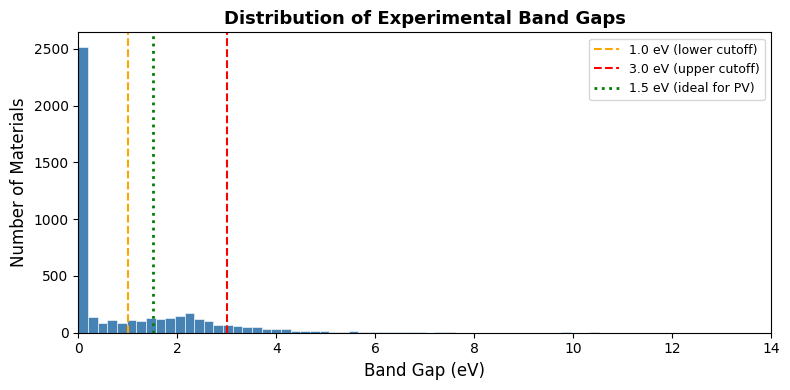

Figure 1 saved.


In [13]:
# ─────────────────────────────────────────────────────────────────
# PLOT 1: Band Gap Distribution
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(y, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(1.0, color='orange', linestyle='--', linewidth=1.5, label='1.0 eV (lower cutoff)')
ax.axvline(3.0, color='red',    linestyle='--', linewidth=1.5, label='3.0 eV (upper cutoff)')
ax.axvline(1.5, color='green',  linestyle=':',  linewidth=2.0, label='1.5 eV (ideal for PV)')

ax.set_xlabel('Band Gap (eV)', fontsize=12)
ax.set_ylabel('Number of Materials', fontsize=12)
ax.set_title('Distribution of Experimental Band Gaps', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 14)

plt.tight_layout()
plt.savefig('fig1_band_gap_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

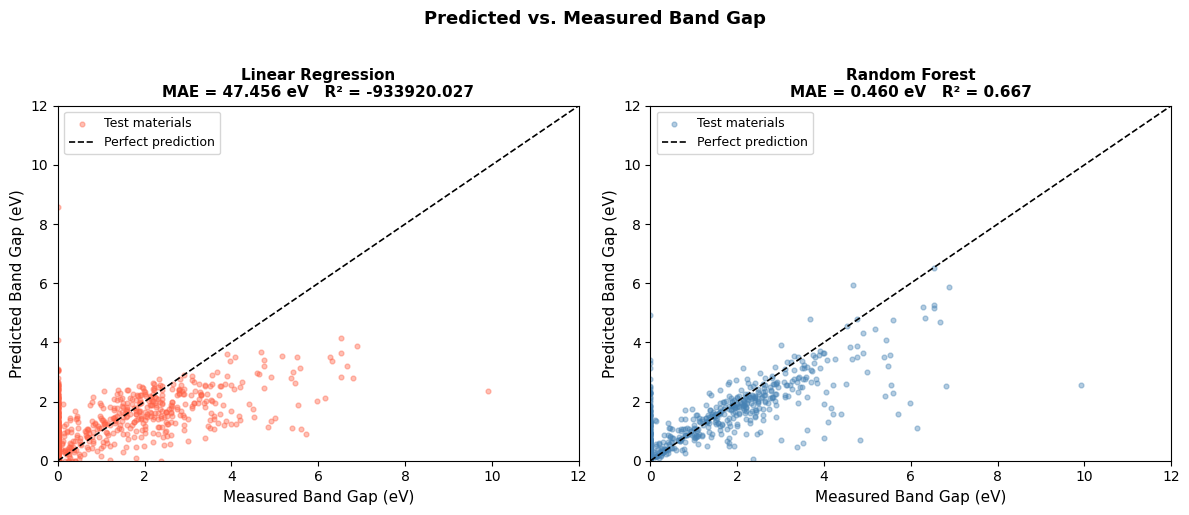

Figure 2 saved.


In [14]:
# ─────────────────────────────────────────────────────────────────
# PLOT 2: Predicted vs. Actual Band Gap (both models)
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

lim = (0, 12)  # axis limits

for ax, y_pred, title, mae, r2, color in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Linear Regression', 'Random Forest'],
    [mae_lr, mae_rf],
    [r2_lr, r2_rf],
    ['tomato', 'steelblue']
):
    ax.scatter(y_test, y_pred, alpha=0.4, s=12, color=color, label='Test materials')
    ax.plot(lim, lim, 'k--', linewidth=1.2, label='Perfect prediction')

    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel('Measured Band Gap (eV)', fontsize=11)
    ax.set_ylabel('Predicted Band Gap (eV)', fontsize=11)
    ax.set_title(f'{title}\nMAE = {mae:.3f} eV   R² = {r2:.3f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Predicted vs. Measured Band Gap', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

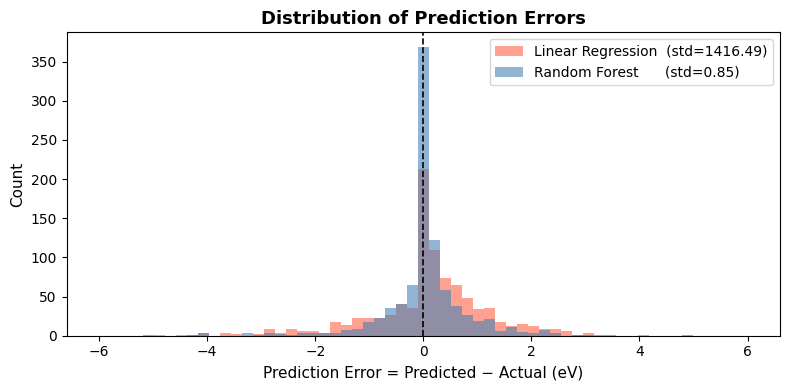

Figure 3 saved.


In [15]:
# ─────────────────────────────────────────────────────────────────
# PLOT 3: Prediction Error Distribution
# ─────────────────────────────────────────────────────────────────
errors_lr = y_pred_lr - y_test
errors_rf = y_pred_rf - y_test

fig, ax = plt.subplots(figsize=(8, 4))

bins = np.linspace(-6, 6, 60)
ax.hist(errors_lr, bins=bins, alpha=0.6, color='tomato',    label=f'Linear Regression  (std={errors_lr.std():.2f})')
ax.hist(errors_rf, bins=bins, alpha=0.6, color='steelblue', label=f'Random Forest      (std={errors_rf.std():.2f})')

ax.axvline(0, color='black', linestyle='--', linewidth=1.2)
ax.set_xlabel('Prediction Error = Predicted − Actual (eV)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Distribution of Prediction Errors', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig3_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

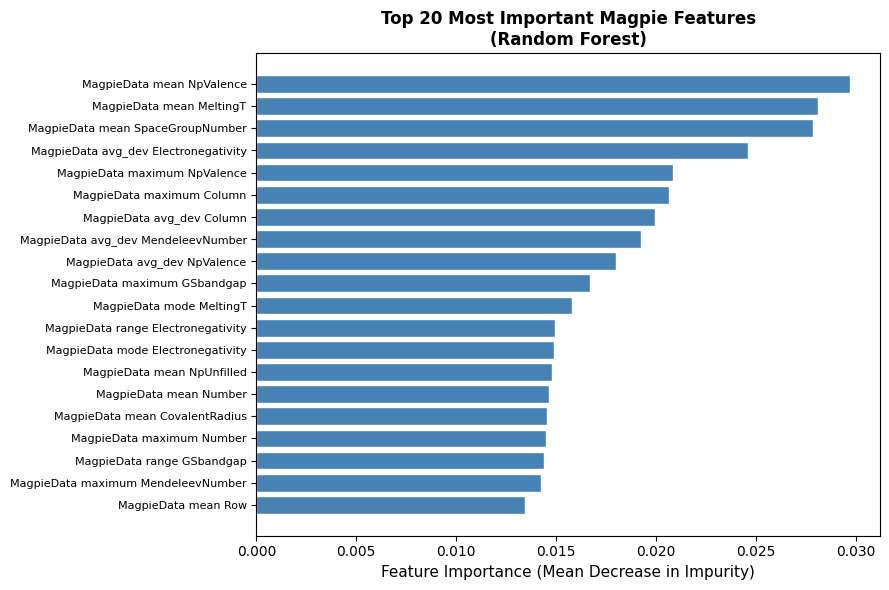

Figure 4 saved.


In [16]:
# ─────────────────────────────────────────────────────────────────
# PLOT 4: Top 20 Feature Importances (Random Forest only)
# ─────────────────────────────────────────────────────────────────
importances = rf.feature_importances_
feat_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    feat_df['feature'][::-1],
    feat_df['importance'][::-1],
    color='steelblue',
    edgecolor='white'
)

ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title('Top 20 Most Important Magpie Features\n(Random Forest)', fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('fig4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

> **Reading the feature importance plot:** Features at the top contribute most to the model's predictions. We expect properties like electronegativity, number of valence electrons, and row in the periodic table to rank highly — these are the key quantum mechanical drivers of electronic band structure.

## Section 13 — Candidate Screening & Ranking

Now we use our trained Random Forest model to **screen the entire dataset** for materials whose predicted band gap falls in the photovoltaic window: **1.0 – 3.0 eV**.

Within that window, we rank materials by their closeness to **1.5 eV** — the theoretical optimum for single-junction solar cells (Shockley–Queisser limit).

In [17]:
# Predict band gaps for ALL materials using Random Forest
y_pred_all = rf.predict(X)

# Build a screening dataframe
screening_df = pd.DataFrame({
    'composition':        df['composition'].values,
    'measured_gap_eV':    np.round(y, 3),
    'predicted_gap_eV':   np.round(y_pred_all, 3),
})

# Screen: predicted gap in the PV window [1.0, 3.0] eV
pv_candidates = screening_df[
    (screening_df['predicted_gap_eV'] >= 1.0) &
    (screening_df['predicted_gap_eV'] <= 3.0)
].copy()

# Rank by closeness to the 1.5 eV target
TARGET_GAP = 1.5  # eV
pv_candidates['distance_from_target'] = np.abs(
    pv_candidates['predicted_gap_eV'] - TARGET_GAP
).round(3)

pv_candidates = pv_candidates.sort_values('distance_from_target')

print(f"Total materials screened:         {len(screening_df)}")
print(f"Candidates in PV window (1–3 eV): {len(pv_candidates)}")
print(f"\nTop 20 candidates closest to {TARGET_GAP} eV:")
print(pv_candidates.head(20).to_string(index=False))

Total materials screened:         4604
Candidates in PV window (1–3 eV): 1437

Top 20 candidates closest to 1.5 eV:
             composition  measured_gap_eV  predicted_gap_eV  distance_from_target
                  TlCdS2             1.50             1.499                 0.001
                  K2TeI6             1.38             1.499                 0.001
            Al0.1In0.9P1             1.50             1.502                 0.002
Zn0.25Ga0.75As0.75Se0.25             1.51             1.504                 0.004
            Yb4Sb2S11.25             1.71             1.505                 0.005
          Ga1As0.99P0.01             1.37             1.494                 0.006
               CsYbMnSe3             1.59             1.493                 0.007
                    YbSe             1.50             1.493                 0.007
                  CsTiF4             0.00             1.507                 0.007
                  CrPbO4             2.25             1.493     

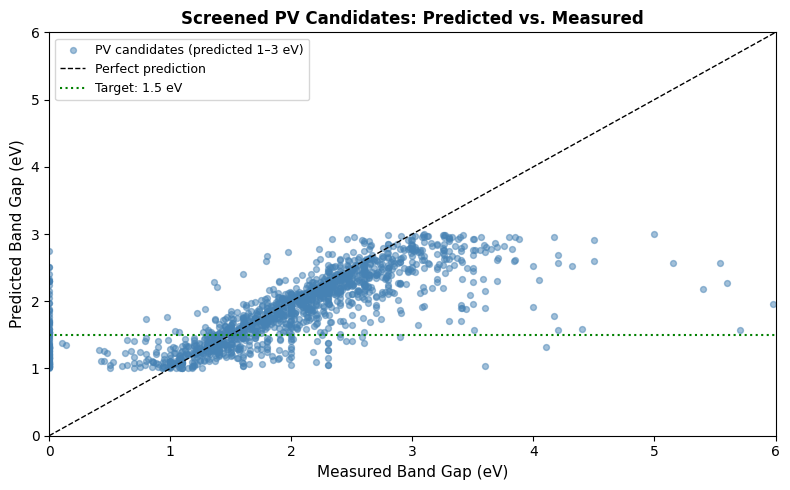

Figure 5 saved.


In [18]:
# ─────────────────────────────────────────────────────────────────
# Visualize: Predicted vs Measured for screened candidates
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    pv_candidates['measured_gap_eV'],
    pv_candidates['predicted_gap_eV'],
    alpha=0.5, s=18, color='steelblue', label='PV candidates (predicted 1–3 eV)'
)

lim = (0, 6)
ax.plot(lim, lim, 'k--', linewidth=1, label='Perfect prediction')
ax.axhline(1.5, color='green', linestyle=':', linewidth=1.5, label='Target: 1.5 eV')

ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel('Measured Band Gap (eV)', fontsize=11)
ax.set_ylabel('Predicted Band Gap (eV)', fontsize=11)
ax.set_title('Screened PV Candidates: Predicted vs. Measured', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig5_screening_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved.")

> The screening step answers the practical question: *which known materials deserve a closer look for solar energy applications?* In a real research workflow, the top candidates would be flagged for DFT calculations or experimental synthesis.

## Section 14 — Export Results to CSV

We export three files:
1. `model_comparison.csv` — MAE and R² for both models
2. `pv_candidates_all.csv` — all materials in the PV window (1–3 eV)
3. `pv_candidates_top50.csv` — top 50 closest to 1.5 eV

In [19]:
# ── 1. Model comparison ────────────────────────────────────────────────────────
comparison_df = pd.DataFrame({
    'Model':              ['Linear Regression', 'Random Forest'],
    'MAE_eV':             [round(mae_lr, 4), round(mae_rf, 4)],
    'R2':                 [round(r2_lr,  4), round(r2_rf,  4)],
    'CV_MAE_mean_eV':     [round(cv_mae_lr.mean(), 4), round(cv_mae_rf.mean(), 4)],
    'CV_MAE_std_eV':      [round(cv_mae_lr.std(),  4), round(cv_mae_rf.std(),  4)]
})
comparison_df.to_csv('model_comparison.csv', index=False)
print("Saved: model_comparison.csv")

# ── 2. All PV window candidates ────────────────────────────────────────────────
pv_candidates.to_csv('pv_candidates_all.csv', index=False)
print(f"Saved: pv_candidates_all.csv  ({len(pv_candidates)} entries)")

# ── 3. Top 50 closest to 1.5 eV ───────────────────────────────────────────────
pv_candidates.head(50).to_csv('pv_candidates_top50.csv', index=False)
print("Saved: pv_candidates_top50.csv  (50 entries)")

print()
print("All results exported successfully.")
print("Files are available in the Colab 'Files' panel (left sidebar, folder icon).")

Saved: model_comparison.csv
Saved: pv_candidates_all.csv  (1437 entries)
Saved: pv_candidates_top50.csv  (50 entries)

All results exported successfully.
Files are available in the Colab 'Files' panel (left sidebar, folder icon).


## Feature Analysis

Elemental properties such as electronegativity and atomic number strongly influence band gap prediction.

## Conclusion

This project demonstrates a simple data-driven workflow for predicting and screening materials based on band gap.

The approach can be extended using structural and stability features.